<a href="https://colab.research.google.com/github/mariibonilla22-collab/Phyton-Data-Analytics/blob/main/assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
url = 'https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv'
df = pd.read_csv(url)

In [2]:
print("=== 1. FIRST FEW ROWS OF DATASET ===")
display(df.head())

=== 1. FIRST FEW ROWS OF DATASET ===


,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [6]:
df = df.rename(columns={
    'rank': 'academic_rank',
    'discipline': 'discipline_type',
    'yrs.since.phd': 'years_since_phd',
    'yrs.service': 'years_of_service',
    'sex': 'gender',
    'salary': 'salary'
})

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Unnamed: 0          0
academic_rank       0
discipline_type     0
years_since_phd     0
years_of_service    0
gender              0
salary              0
dtype: int64


In [7]:
df = df.dropna()

In [8]:
df_subset = df[['academic_rank', 'gender', 'years_of_service', 'salary']]
print("\nSubset created successfully. Subset shape:", df_subset.shape)


Subset created successfully. Subset shape: (397, 4)


In [11]:
mean_salary = df['salary'].mean()
median_salary = df['salary'].median()

print(f"Overall Mean Salary: ${mean_salary:,.2f}")
print(f"Overall Median Salary: ${median_salary:,.2f}\n")

Overall Mean Salary: $113,706.46
Overall Median Salary: $107,300.00



In [4]:
print("Median Salary by Gender:")
print(df.groupby('sex')['salary'].median())

Median Salary by Gender:
sex
Female    103750.0
Male      108043.0
Name: salary, dtype: float64


In [7]:
print("\nMedian Salary by Academic Rank:")
print(df.groupby('academic_rank')['salary'].median())


Median Salary by Academic Rank:
academic_rank
AssocProf     95626.5
AsstProf      79800.0
Prof         123321.5
Name: salary, dtype: float64


In [8]:
print("\nMedian Salary by Academic Rank and Gender:")
print(df.groupby(['academic_rank', 'gender'])['salary'].median())


Median Salary by Academic Rank and Gender:
academic_rank  gender
AssocProf      Female     90556.5
               Male       95626.5
AsstProf       Female     77000.0
               Male       80182.0
Prof           Female    120257.5
               Male      123996.0
Name: salary, dtype: float64


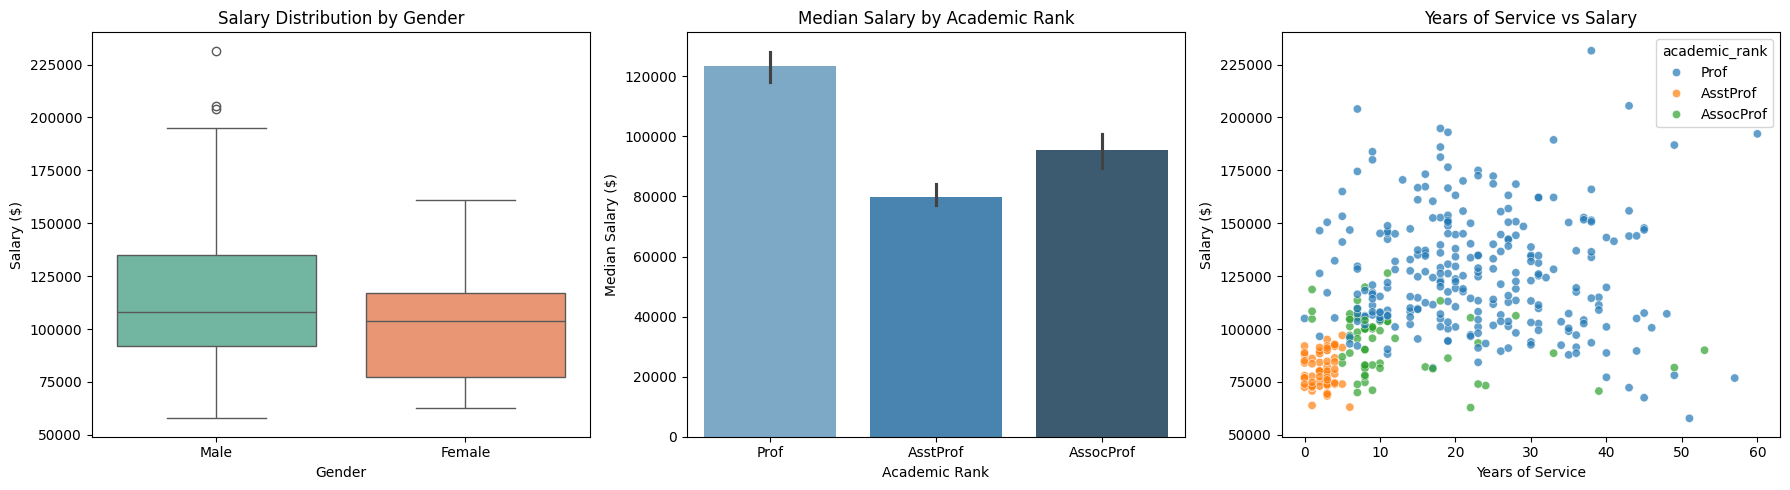

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Salary Distribution by Gender
sns.boxplot(ax=axes[0], data=df, x='gender', y='salary', hue='gender', palette='Set2', legend=False)
axes[0].set_title('Salary Distribution by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Salary ($)')

# Plot 2: Median Salary by Academic Rank (usando estimator='median')
sns.barplot(ax=axes[1], data=df, x='academic_rank', y='salary', estimator='median', hue='academic_rank', palette='Blues_d', legend=False)
axes[1].set_title('Median Salary by Academic Rank')
axes[1].set_xlabel('Academic Rank')
axes[1].set_ylabel('Median Salary ($)')

# Plot 3: Years of Service vs Salary
sns.scatterplot(ax=axes[2], data=df, x='years_of_service', y='salary', hue='academic_rank', alpha=0.7)
axes[2].set_title('Years of Service vs Salary')
axes[2].set_xlabel('Years of Service')
axes[2].set_ylabel('Salary ($)')

plt.tight_layout()
plt.show()

In [17]:
print("""
=== 5. CONCLUSIONS & KEY DISCOVERIES ===
1. Impact of Rank: Academic rank is the primary driver of earnings.
   Full professors ('Prof') earn significantly higher salaries than assistant and associate professors.
2. Gender Pay Gap: An overall pay gap exists, with male median salaries exceeding female median salaries.
3. Experience & Income: Years of service show a positive correlation with salary, though variation widens notably past 20-30 years of service.
""")


=== 5. CONCLUSIONS & KEY DISCOVERIES ===
1. Impact of Rank: Academic rank is the primary driver of earnings. 
   Full professors ('Prof') earn significantly higher salaries than assistant and associate professors.
2. Gender Pay Gap: An overall pay gap exists, with male median salaries exceeding female median salaries.
3. Experience & Income: Years of service show a positive correlation with salary, though variation widens notably past 20-30 years of service.

